In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

### Load MNIST Dataset

In [30]:
df = keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = df
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [31]:
data_train = pd.read_csv(r"mnist_train.csv")
data_test = pd.read_csv(r"mnist_test.csv")
print(data_train.shape, data_test.shape)

(60000, 785) (10000, 785)


In [32]:
data_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
y_train = data_train["label"].values
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

In [34]:
x_train = data_train.drop("label", axis=1).values
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784))

In [35]:
y_test = data_test["label"].values
x_test = data_test.drop("label", axis=1).values

print(x_test.shape, y_test.shape)

(10000, 784) (10000,)


**Normalizing X_train and X_test data**

In [36]:
x_train = x_train.astype("float") / 255
x_test = x_test.astype("float") / 255
type(x_train)

numpy.ndarray

### Neural Network

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [ ]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

c:\Ayush\mca\Deep Learning\dl-sheryians\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compiling the Sequential Model**

In [39]:
# one hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [40]:
x_train_img = x_train.reshape(-1, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)

In [41]:

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

### Training the Model

In [42]:
history_ann = model.fit(x_train_img, y_train_cat, epochs=10, batch_size=32, validation_data=(x_test_img, y_test_cat), verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9296 - loss: 0.2368 - val_accuracy: 0.9598 - val_loss: 0.1270
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9694 - loss: 0.1005 - val_accuracy: 0.9724 - val_loss: 0.0894
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9778 - loss: 0.0717 - val_accuracy: 0.9727 - val_loss: 0.0889
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9833 - loss: 0.0527 - val_accuracy: 0.9705 - val_loss: 0.0927
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9859 - loss: 0.0422 - val_accuracy: 0.9760 - val_loss: 0.0793
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9889 - loss: 0.0345 - val_accuracy: 0.9770 - val_loss: 0.0811
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9903 - loss: 0.0292 - val_accuracy: 0.9800 - val_loss: 0.0765
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9918 - loss: 0.0248 - 

In [43]:
acc_ann = model.evaluate(x_test_img, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9768 - loss: 0.0936


In [44]:
acc_ann

[0.09359857439994812, 0.9768000245094299]

In [46]:
print(f"Accuracy : {acc_ann[1]}\nLoss : {acc_ann[0]}")

Accuracy : 0.9768000245094299
Loss : 0.09359857439994812


**Modifying Learning Rates**

In [47]:
from tensorflow.keras.optimizers import Adam

In [48]:
custom_adam1 = Adam(learning_rate=0.01)
custom_adam2 = Adam(learning_rate=0.001)
custom_adam3 = Adam(learning_rate=0.0001)

> Learning Rate : 0.01, Batch Size : 32

In [49]:
model.compile(optimizer=custom_adam1, loss="categorical_crossentropy", metrics=["accuracy"])

In [50]:
model.fit(x_train_img, y_train_cat, epochs=10, batch_size=32, verbose=1, validation_data=(x_test_img, y_test_cat))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9460 - loss: 0.2015 - val_accuracy: 0.9488 - val_loss: 0.1984
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9543 - loss: 0.1719 - val_accuracy: 0.9543 - val_loss: 0.1864
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9616 - loss: 0.1499 - val_accuracy: 0.9622 - val_loss: 0.1695
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9632 - loss: 0.1468 - val_accuracy: 0.9647 - val_loss: 0.1525
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9682 - loss: 0.1306 - val_accuracy: 0.9624 - val_loss: 0.1824
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9701 - loss: 0.1231 - val_accuracy: 0.9568 - val_loss: 0.2035
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9714 - loss: 0.1204 - val_accuracy: 0.9634 - val_loss: 0.1689
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9730 - loss: 0.1111 - 

In [51]:
model1_data = model.evaluate(x_test_img, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9676 - loss: 0.1828


In [52]:
print("Learning Rate : 0.01, Batch Size : 32, Accuracy gone : ")
print(model1_data[1])

Learning Rate : 0.01, Batch Size : 32, Accuracy gone : 
0.9675999879837036


> Other two learning rates can be done in similar ways

## Visualizing our Model Performance

In [53]:
import matplotlib.pyplot as plt

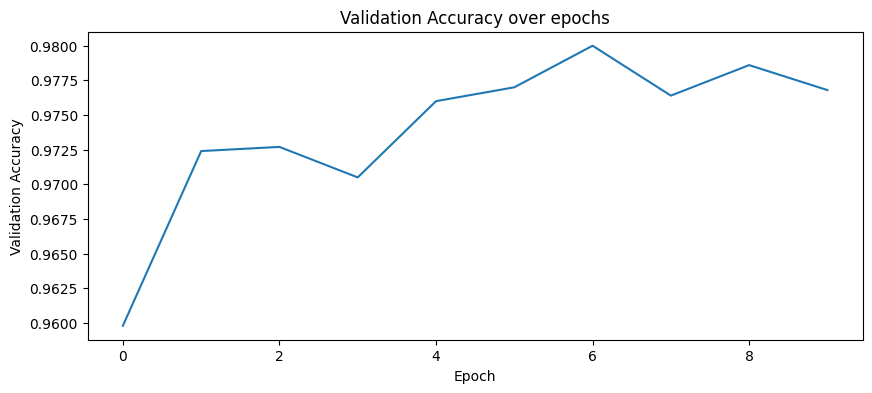

In [60]:
plt.figure(figsize=(10,4))
plt.plot(history_ann.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy over epochs")
plt.show()

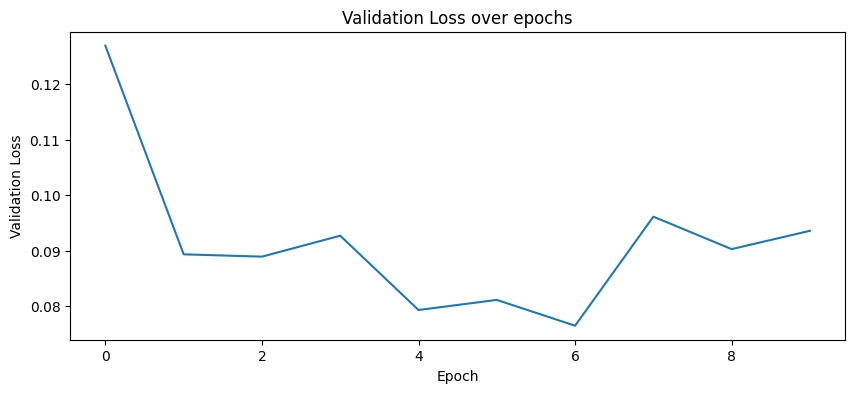

In [61]:
plt.figure(figsize=(10,4))
plt.plot(history_ann.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss over epochs")
plt.show()

In [89]:
def predict(xImg) :
    pred = model.predict(xImg.reshape(1,28,28,1))
    return pred.argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


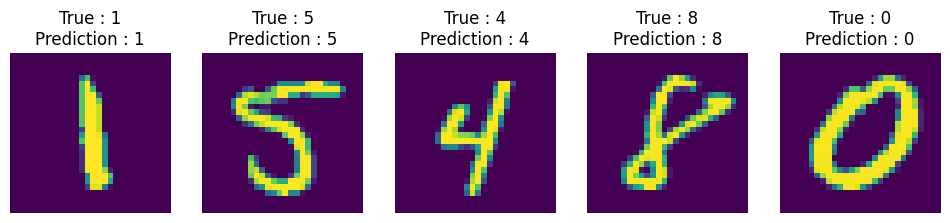

In [91]:
plt.figure(figsize=(12,6))
for i in range(5) :
    idx = np.random.randint(len(x_test_img))
    prediction = predict(x_test_img[idx])
    true = y_test[idx]
    plt.subplot(1, 5, i+1)
    plt.axis("off")
    label = "True : " + str(true) + "\n"
    label += "Prediction : " + str(prediction)
    plt.title(label)
    plt.imshow(x_test_img[idx])